In [ ]:
import math
import inspect
import numpy as np
from typing import List, Tuple
import random
import matplotlib.pyplot as plt

from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Callable, List

import json
import numpy as np
from pathlib import Path
import random
from datetime import datetime

print(torch.cuda.is_available())

True


In [ ]:
"""
Full definition of a GPT Language Model, all of it in this single file ,adapted from https://github.com/karpathy/nanoGPT/blob/master/model.py.
References:
1) the official GPT-2 TensorFlow implementation released by OpenAI:
https://github.com/openai/gpt-2/blob/master/src/model.py
2) huggingface/transformers PyTorch implementation:
https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py
"""

class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster
    # TODO: add a tokenizer option

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # with weight tying when using torch.compile() some warnings get generated:
        # "UserWarning: functional_call was passed multiple values for tied weights.
        # This behavior is deprecated and will be an error in future versions"
        # not 100% sure what this is, so far seems to be harmless. TODO investigate
        self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)
        # apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)


        return logits

    def crop_block_size(self, block_size):
        # model surgery to decrease the block size if necessary
        # e.g. we may load the GPT2 pretrained model checkpoint (block size 1024)
        # but want to use a smaller block size for some smaller, simpler model
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:,:,:block_size,:block_size]


    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
        print(f"using fused AdamW: {use_fused}")


In [ ]:
#TOKENIZER
"""
<s> = begining of sentence token
</s> = end of sentence token
<UNK> = unknown token
<PAD> = padding token
"""

class tokenizer:
    def __init__(self) -> None:
        self.vocab = set()
        self.vocab_index_mapping = None
        self.index_vocab_mapping = None

    def build_vocab(self, data: list[str]) -> None:
        self.vocab = set()
        special_tokens = ["<s>", "</s>", "<UNK>", "<PAD>"]
        for string in data:
            self.vocab.update(string.lower().split())
        self.vocab = sorted(self.vocab)
        self.vocab_index_mapping = {token: i for i, token in enumerate(self.vocab, start=4)}
        for i in range(len(special_tokens)):
            self.vocab_index_mapping[special_tokens[i]] = i
        self.index_vocab_mapping = {i: token for token, i in self.vocab_index_mapping.items()}

    def encoding(self, input: str) -> list[int]:
        encoded_input = [self.vocab_index_mapping["<s>"]] + [self.vocab_index_mapping.get(token, self.vocab_index_mapping["<UNK>"]) for token in input.lower().split()] + [self.vocab_index_mapping["</s>"]]
        return encoded_input

    def decoding(self, encoded_input: list[int]) -> str:
        decoded_input = ""
        for index in encoded_input:
            decoded_input += self.index_vocab_mapping[index] + " "
        return decoded_input[:-1]
        #tokens = [self.index_vocab_mapping[i] for i in encoded_input if self.index_vocab_mapping[i] not in {"<s>", "</s>", "<PAD>"}]
        #return " ".join(tokens)

In [19]:
#DATA GENERATION

def generate_data(
        p:int = 97,
        train_split:float = 0.8,
        val_split:float = 0.2,
        ops:List[str] = ['+', '-', '/'],
        seed:int = 42,
        output_dir:str = None) -> Tuple[List[str]]:

    random.seed(seed)
    data = []

    for op in ops:
        for a in range(p):
            for b in range(p):
                res = None
                if op=='+':
                    res = (a + b) % p
                elif op == '-':
                    res = (a - b) % p
                elif op == '/' and b != 0:
                    res = a * pow(b, -1, p) % p
                else:
                    continue

                data.append(f'{a} {op} {b} = {res}')

    random.shuffle(data)
    train_end = int(train_split * len(data))
    val_end = train_end + int(val_split * len(data))
    train = data[:train_end]
    val = data[train_end:val_end]
    test = data[val_end:]

    if output_dir:
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)
        with open(output_path / f"train_{p}.txt", "w") as f:
            f.write("\n".join(train))
        with open(output_path / f"val_{p}.txt", "w") as f:
            f.write("\n".join(val))
        with open(output_path / f"test_{p}.txt", "w") as f:
            f.write("\n".join(test))

    return (train, val, test)


In [ ]:
#NEW TRAIN
def _save_checkpoint(path, config, model, tok):
    torch.save({
        "model_config": config.__dict__.copy(),
        "model": model.state_dict(),
        "tokenizer": {
            "vocab": sorted(tok.vocab),
            "vocab_index_mapping": tok.vocab_index_mapping,
            "index_vocab_mapping": tok.index_vocab_mapping,
        },
    }, path)


OPERATORS = ["+", "-", "/"]
OPERATOR_TO_ID = {op: i for i, op in enumerate(OPERATORS)}


def _save_metrics(path, metrics):
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)


def _new_run_dir(output_dir=None):
    if output_dir is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        run_dir = Path("runs") / f"run_{timestamp}"
        run_dir.mkdir(parents=True, exist_ok=False)
    else:
        run_dir = Path(output_dir)
        run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def all_tokens_mask(ids, text, tok):
    return [1] * (len(ids) - 1)


def suffix_after_n_input_tokens(n):
    def mask_fn(ids, text, tok):
        mask = [0] * (len(ids) - 1)
        start = min(n, len(mask))
        mask[start:] = [1] * (len(mask) - start)
        return mask
    return mask_fn


def token_after_marker(marker):
    def mask_fn(ids, text, tok):
        marker_id = tok.vocab_index_mapping[marker]
        marker_idx = ids.index(marker_id)
        mask = [0] * (len(ids) - 1)
        if marker_idx < len(mask):
            mask[marker_idx] = 1
        return mask
    mask_fn.marker = marker
    return mask_fn


modulo_answer_mask = token_after_marker("=")
modulo_answer_mask.is_modulo_answer_mask = True


class Custom_Dataset(Dataset):
    def __init__(self, strings, tok, mask_fn, collect_operator_metrics=False):
        self.strings = strings
        self.tok = tok
        self.mask_fn = mask_fn
        self.collect_operator_metrics = collect_operator_metrics

    def __len__(self):
        return len(self.strings)

    def __getitem__(self, idx):
        text = self.strings[idx]
        ids = self.tok.encoding(text)
        mask = self.mask_fn(ids, text, self.tok)
        op_id = -1
        if self.collect_operator_metrics:
            for op in OPERATORS:
                if f" {op} " in text:
                    op_id = OPERATOR_TO_ID[op]
                    break
        return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.float), torch.tensor(op_id, dtype=torch.long)


def _empty_epoch_stats():
    return {"loss_sum": 0.0, "correct": 0, "total": 0.0}


def _empty_operator_epoch_stats():
    return {op: _empty_epoch_stats() for op in OPERATORS}


def _append_epoch_metrics(metrics, split, stats, operator_stats=None):
    metrics["combined"][f"{split}_losses"].append(stats["loss_sum"] / stats["total"])
    metrics["combined"][f"{split}_accs"].append(stats["correct"] / stats["total"])

    if operator_stats is None:
        return

    for op, op_stats in operator_stats.items():
        if op_stats["total"] == 0:
            metrics["by_operator"][op][f"{split}_losses"].append(None)
            metrics["by_operator"][op][f"{split}_accs"].append(None)
        else:
            metrics["by_operator"][op][f"{split}_losses"].append(op_stats["loss_sum"] / op_stats["total"])
            metrics["by_operator"][op][f"{split}_accs"].append(op_stats["correct"] / op_stats["total"])


def __infer_step(batch, model, stats, device, operator_stats=None):
    batch, loss_mask, op_ids = batch
    batch = batch.to(device)
    loss_mask = loss_mask.to(device)
    op_ids = op_ids.to(device)
    x = batch[:, :-1]
    y = batch[:, 1:]

    logits = model(x)
    token_losses = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        y.reshape(-1),
        reduction="none",
    ).view_as(y)
    num_masked = loss_mask.sum()
    if num_masked.item() == 0:
        raise ValueError("loss mask must select at least one token in each batch")
    loss = (token_losses * loss_mask).sum() / num_masked

    preds = logits.argmax(dim=-1)
    correct_by_token = ((preds == y) * loss_mask.bool()).float()

    loss_by_example = (token_losses * loss_mask).sum(dim=1)
    correct_by_example = correct_by_token.sum(dim=1)
    total_by_example = loss_mask.sum(dim=1)

    stats["loss_sum"] += loss_by_example.sum().item()
    stats["correct"] += correct_by_example.sum().item()
    stats["total"] += total_by_example.sum().item()

    if operator_stats is not None:
        for op, op_id in OPERATOR_TO_ID.items():
            op_mask = op_ids == op_id
            if op_mask.any():
                operator_stats[op]["loss_sum"] += loss_by_example[op_mask].sum().item()
                operator_stats[op]["correct"] += correct_by_example[op_mask].sum().item()
                operator_stats[op]["total"] += total_by_example[op_mask].sum().item()

    return loss


def train(
        tok:tokenizer,
        train_data:List[str],
        val_data:List[str],
        batch_size:int,
        block_size:int,
        n_layer:int,
        n_head:int,
        n_embd:int,
        dropout:float,
        bias:bool,
        learning_rate:float,
        epochs:int,
        seed:int,
        mask_fn:Callable = modulo_answer_mask,
        output_dir:str = None,
        intermediate_ckpt:bool = True,
        verbose:bool = False,
        weight_decay:float = 1.0,
        beta1:float = 0.9,
        beta2:float = 0.98,
        warmup_steps:int = 10):

    device = 'cuda' if torch.cuda.is_available() else "cpu"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


    run_dir = _new_run_dir(output_dir)
    collect_operator_metrics = getattr(mask_fn, "is_modulo_answer_mask", False)

    train_ds = Custom_Dataset(train_data, tok, mask_fn, collect_operator_metrics)
    train_loader = DataLoader(train_ds, batch_size=batch_size)
    val_ds = Custom_Dataset(val_data, tok, mask_fn, collect_operator_metrics)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    config = GPTConfig(
        vocab_size=len(tok.vocab_index_mapping),
        block_size=block_size,
        n_layer=n_layer,
        n_head=n_head,
        n_embd=n_embd,
        dropout=dropout,
        bias=bias,
    )

    model = GPT(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(beta1, beta2), weight_decay=weight_decay)

    ckpt_iter = epochs // 2

    metrics = {
        "combined": {
            "train_losses": [],
            "train_accs": [],
            "val_losses": [],
            "val_accs": [],
        },
    }
    if collect_operator_metrics:
        metrics["by_operator"] = {
            op: {
                "train_losses": [],
                "train_accs": [],
                "val_losses": [],
                "val_accs": [],
            }
            for op in OPERATORS
        }

    epoch_iter = range(epochs)
    progress = None
    if verbose:
        try:
            from tqdm import tqdm
            progress = tqdm(epoch_iter, desc="training", leave=True)
            epoch_iter = progress
        except ImportError:
            progress = None

    global_step = 0
    for i in epoch_iter:

        model.train()
        train_stats = _empty_epoch_stats()
        train_operator_stats = _empty_operator_epoch_stats() if collect_operator_metrics else None

        for batch in train_loader:
            loss = __infer_step(batch, model, train_stats, device, train_operator_stats)

            global_step += 1
            if warmup_steps > 0 and global_step <= warmup_steps:
                lr = learning_rate * global_step / warmup_steps
            else:
                lr = learning_rate

            for param_group in optimizer.param_groups:
                param_group["lr"] = lr

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        _append_epoch_metrics(metrics, "train", train_stats, train_operator_stats)


        model.eval()
        val_stats = _empty_epoch_stats()
        val_operator_stats = _empty_operator_epoch_stats() if collect_operator_metrics else None
        with torch.no_grad():
            for batch in val_loader:
                __infer_step(batch, model, val_stats, device, val_operator_stats)
        _append_epoch_metrics(metrics, "val", val_stats, val_operator_stats)

        if progress is not None:
            progress.set_postfix(
                train_loss=metrics["combined"]["train_losses"][-1],
                train_acc=metrics["combined"]["train_accs"][-1],
                val_loss=metrics["combined"]["val_losses"][-1],
                val_acc=metrics["combined"]["val_accs"][-1],
            )
        elif verbose:
            print(
                f"epoch {i + 1}/{epochs} "
                f"train_loss={metrics['combined']['train_losses'][-1]:.6f} "
                f"train_acc={metrics['combined']['train_accs'][-1]:.4f} "
                f"val_loss={metrics['combined']['val_losses'][-1]:.6f} "
                f"val_acc={metrics['combined']['val_accs'][-1]:.4f}"
            )

        completed_epochs = i + 1
        if intermediate_ckpt and completed_epochs == ckpt_iter:
            _save_checkpoint(run_dir / f'ckpt_{completed_epochs}_epochs.pt', config, model, tok)



    _save_checkpoint(run_dir / f'ckpt_{epochs}_epochs.pt', config, model, tok)
    metrics["run_dir"] = str(run_dir)
    _save_metrics(run_dir / "metrics.json", metrics)

    return metrics, model

In [ ]:
#INFERENCE
"""
Assumes model is saved as:
torch.save({"model_config": config_dict, "model": model.state_dict(), "tokenizer": tokenizer_state}, "ckpt.pt")
"""

def load_model(checkpoint_loc: str, device='cuda' if torch.cuda.is_available() else "cpu") -> GPT:
    checkpoint = torch.load(checkpoint_loc, map_location=device)
    config = GPTConfig(**checkpoint["model_config"])
    model = GPT(config)
    model.load_state_dict(checkpoint["model"])
    model.to(device)
    model.eval()
    return model

def load_tokenizer(checkpoint_loc: str) -> tokenizer:
    checkpoint = torch.load(checkpoint_loc, map_location='cuda' if torch.cuda.is_available() else "cpu")
    tok = tokenizer()
    state = checkpoint.get("tokenizer")
    if state is None:
        return tok
    tok.vocab = set(state["vocab"])
    tok.vocab_index_mapping = state["vocab_index_mapping"]
    tok.index_vocab_mapping = state["index_vocab_mapping"]
    return tok

def load_model_and_tokenizer(checkpoint_loc: str, device="cpu") -> tuple[GPT, tokenizer]:
    return load_model(checkpoint_loc, device), load_tokenizer(checkpoint_loc)

def generate_output(
    model: GPT,
    tokenizer,
    input: str,
    output_size: int,
    add_eos_to_prompt: bool = False,
) -> str: # may need to increase output size by two to account for SOS and EOS tokens
    tokens = [tokenizer.vocab_index_mapping["<s>"]]
    tokens += [
        tokenizer.vocab_index_mapping.get(token, tokenizer.vocab_index_mapping["<UNK>"])
        for token in input.lower().split()
    ]
    device = next(model.parameters()).device
    tokens = torch.tensor([tokens], dtype=torch.long, device=device)
    with torch.no_grad():
        for _ in range(output_size):
            output = model(tokens)
            logits = output[:, -1, :]
            prediction = logits.argmax(dim=-1, keepdim=True)
            tokens = torch.cat([tokens, prediction], dim=1)
    if add_eos_to_prompt:
      tokens.append(tokenizer.vocab_index_mapping["</s>"])
    return tokenizer.decoding(tokens[0].tolist())


number of parameters: 0.41M


training: 100%|██████████| 2000/2000 [08:24<00:00,  3.97it/s, train_acc=1, train_loss=0.0145, val_acc=1, val_loss=0.00327]


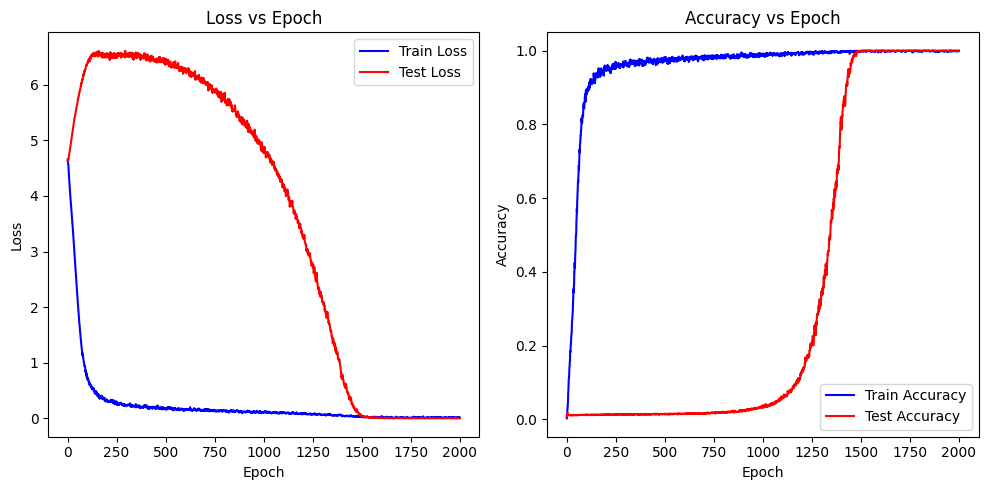

In [ ]:
#MAIN


def validation_split(data: list[str], val_split=0.2, seed:int=42) -> Tuple[List[str]]:
    random.seed(seed)
    random.shuffle(data)
    split = int(val_split * len(data))
    val = data[:split]
    train = data[split:]
    return (train, val)

train_set, val_set, test_set = generate_data(p=97, train_split=0.19, val_split=0.0, ops=['/'], seed=42, output_dir="1_3_Grok")

#train_set, val_set = validation_split(train_set)
epochs = 2000
tok = tokenizer()
tok.build_vocab(train_set)

metrics, model = train(
        tok,
        train_set,
        test_set,
        batch_size=512,
        block_size=16,
        n_layer=2,
        n_head=4,
        n_embd=128,
        dropout=0.1,
        bias=True,
        learning_rate=1e-3,
        epochs=epochs,
        seed=42,
        output_dir="1_3_Grok",
        intermediate_ckpt=False,
        verbose=True,
        weight_decay=1.0,
        beta1=0.9,
        beta2=0.98,
        warmup_steps=10)

train_loss = metrics["combined"]["train_losses"]
train_accuracy = metrics["combined"]["train_accs"]
val_loss = metrics["combined"]["val_losses"]
val_accuracy = metrics["combined"]["val_accs"]

X = np.arange(1, epochs+1, 1)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
#fig.suptitle(f"Accuracy and Loss Graphs for p=97 under the Division Operator Training on 25% of Total Data")

axs[0].plot(X, train_loss, color="blue", label="Train Loss")
axs[0].plot(X, val_loss, color="red", label="Test Loss")
axs[0].set_title("Loss vs Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend(loc="upper right")

axs[1].plot(X, train_accuracy, color="blue", label="Train Accuracy")
axs[1].plot(X, val_accuracy, color="red", label="Test Accuracy")
axs[1].set_title("Accuracy vs Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend(loc="lower right")

fig.tight_layout()
plt.show()